In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime

In [2]:
%load_ext tensorboard

In [3]:
LOGS_BASE_PATH = os.path.join("logs")
def get_current_time():
    return datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

device = "cpu"
dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [5]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

## Setup the dataset

In [6]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf[["username", "id", "affinity"] + spoti.NUMERICAL_FEATURES]
df_matrix_mf["affinity"] *= 100
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_53185/439537998.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


In [7]:
preprocessing.count_number_of_occurence(df_matrix_mf, "id")

id
0DiWol3AO6WpXZgp0goxAV    4
0U0ldCRmgCqhVvD6ksG63j    4
11HLDMuPD3wh88XHw4udKO    4
2Fxmhks0bxGSBdJ92vM42m    4
48UPSzbZjgc449aqz8bxox    4
                         ..
2gQaQUhDCNGfBVXTvxAmXQ    1
2gQYziDV5cSTRSqr6akzi5    1
2gJuY2L6eCxAfIXdXAWtm5    1
2gG4tJcTOLa8tWy4GiQ8A9    1
7zzl5nLmPPkAwk2MRIUpa4    1
Name: count, Length: 6320, dtype: int64

In [8]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 2)
df_matrix_mf_filtered[spoti.PRETTY_PRINT_FEATURES].sort_values("name")

,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
1444,jaslkh,$uicideboy$,$outh $ide $uicide,2015,73,0.797,0.516,0.0832,0.00538,0.438000,0.0728,0.0478,109.993,-6.286,169319,2015,73
2671,owen,$uicideboy$,$outh $ide $uicide,2015,74,0.797,0.516,0.0832,0.00538,0.438000,0.0728,0.0478,109.993,-6.286,169319,2015,74
3424,owen,Blue Öyster Cult,(Don't Fear) The Reaper,1976,81,0.333,0.927,0.0733,0.00290,0.000208,0.2970,0.3850,141.466,-8.550,308120,1976,81
7756,arthur,Blue Öyster Cult,(Don't Fear) The Reaper,1976,81,0.333,0.927,0.0733,0.00290,0.000208,0.2970,0.3850,141.466,-8.550,308120,1976,81
1534,owen,MCR-T,1-800-GHETTOLICIOUS,2023,46,0.875,0.837,0.1480,0.00143,0.045200,0.1450,0.8140,136.994,-8.386,262773,2023,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,jaslkh,Damso,Φ. THEVIE RADIO,2021,47,0.500,0.454,0.1260,0.12200,0.000000,0.2660,0.2790,130.711,-11.701,234528,2021,47
2092,owen,美波,カワキヲアメク,2019,71,0.541,0.846,0.0551,0.01220,0.000149,0.1630,0.5240,129.138,-2.729,251933,2019,71
8912,michelle,美波,カワキヲアメク,2019,71,0.541,0.846,0.0551,0.01220,0.000149,0.1630,0.5240,129.138,-2.729,251933,2019,71
8270,michelle,Fujii Kaze,死ぬのがいいわ,2020,68,0.600,0.760,0.0451,0.16700,0.000041,0.1890,0.5190,158.075,-6.123,185573,2020,68


In [9]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 8 users, 6320 items and 917 interactions, so the sparsity is 1.81%.


In [10]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
shuffled_users_df

username
owen         274
michelle     116
jaslkh       112
paul         112
lsirwguhu    108
arthur        81
brenda        69
dany          45
Name: count, dtype: int64

,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu
paul,112,paul
brenda,69,brenda


In [11]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.2, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu
paul,112,paul
brenda,69,brenda


Train data:


,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany


Validation data:


,count,old_index
username,,
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu


Test data:


,count,old_index
username,,
paul,112,paul
brenda,69,brenda


In [12]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
train_df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
1505,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,239597,False,{'isrc': 'TCACP1635569'},{'spotify': 'https://open.spotify.com/track/4y...,https://api.spotify.com/v1/tracks/4yXKLDrHYrff...,4yXKLDrHYrffSVmQOFdbDA,...,medium_term,100.0,owen,2016,"[emo, emo, emo, indie, emo]",NaT,NaN,NaN,NaN,NaN
1507,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,276000,True,{'isrc': 'TCACP1635556'},{'spotify': 'https://open.spotify.com/track/19...,https://api.spotify.com/v1/tracks/19aUuDd6udp1...,19aUuDd6udp1ACNo9t3IuZ,...,medium_term,96.0,owen,2016,"[emo, emo, emo, indie, emo]",NaT,NaN,NaN,NaN,NaN
1514,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,250546,False,{'isrc': 'USRW29600011'},{'spotify': 'https://open.spotify.com/track/5U...,https://api.spotify.com/v1/tracks/5UWwZ5lm5PKu...,5UWwZ5lm5PKu6eKsHAGxOk,...,medium_term,82.0,owen,1997,"[metal, rock, rock, emo, grunge, rock]",NaT,NaN,NaN,NaN,NaN
1517,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, BE, BG, BH, BO, BR, CA, CH, C...",1,193911,False,{'isrc': 'QMCE71300252'},{'spotify': 'https://open.spotify.com/track/5b...,https://api.spotify.com/v1/tracks/5bwxMo2sye4b...,5bwxMo2sye4bffTgp7uNbo,...,medium_term,76.0,owen,2015,"[emo, lofi, emo, emo]",NaT,NaN,NaN,NaN,NaN
1519,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,265360,True,{'isrc': 'USRC12301954'},{'spotify': 'https://open.spotify.com/track/7d...,https://api.spotify.com/v1/tracks/7dJYggqjKo71...,7dJYggqjKo71KI9sLzqCs8,...,medium_term,72.0,owen,2023,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12386,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,365626,False,{'isrc': 'GBAYE7800619'},{'spotify': 'https://open.spotify.com/track/5g...,https://api.spotify.com/v1/tracks/5gOd6zDC8vhl...,5gOd6zDC8vhlYjqbQdJVWP,...,NaN,50.0,dany,1978,"[rock, rock, rock, rock, rock]",2019-12-09 06:53:08+00:00,NaN,NaN,NaN,NaN
12390,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,1413306,False,{'isrc': 'GBN9Y1100065'},{'spotify': 'https://open.spotify.com/track/1M...,https://api.spotify.com/v1/tracks/1Mzm1CNqVxtw...,1Mzm1CNqVxtwbCYhOo843s,...,NaN,30.0,dany,1971,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:49:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12393,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,284413,False,{'isrc': 'GBN9Y1100080'},{'spotify': 'https://open.spotify.com/track/25...,https://api.spotify.com/v1/tracks/25tZHMv3ctlz...,25tZHMv3ctlzqDaHAeuU9c,...,NaN,30.0,dany,1973,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:50:19+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12399,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,304200,False,{'isrc': 'GBN9Y1100088'},{'spotify': 'https://open.spotify.com/track/7a...,https://api.spotify.com/v1/tracks/7aE5WXu5sFeN...,7aE5WXu5sFeNRh3Z05wwu4,..

In [13]:
val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
display(val_df_train[spoti.PRETTY_PRINT_FEATURES])
display(val_df_test[spoti.PRETTY_PRINT_FEATURES])

,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
15,jaslkh,Disiz,Qu'ils ont de la chance,2017,55,0.702,0.403,0.0347,0.77300,0.000226,0.2840,0.438,137.925,-10.310,282052,2017,55
23,jaslkh,Pixies,All I Think About Now,2016,70,0.251,0.575,0.0311,0.00405,0.001350,0.1500,0.218,185.731,-7.819,187320,2016,70
36,jaslkh,Françoise Hardy,Le temps de l'amour,1962,65,0.586,0.412,0.0334,0.79800,0.000000,0.1520,0.706,132.199,-10.116,144826,1962,65
43,jaslkh,Supertramp,The Logical Song - Remastered 2010,1979,77,0.625,0.758,0.0463,0.51200,0.000220,0.1530,0.695,119.719,-6.213,251253,1979,77
72,jaslkh,Rihanna,Love On The Brain,2016,87,0.509,0.637,0.0471,0.07170,0.000011,0.0789,0.378,172.006,-4.830,224000,2016,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12128,lsirwguhu,Rihanna,Love On The Brain,2016,86,0.509,0.637,0.0471,0.07170,0.000011,0.0789,0.378,172.006,-4.830,224000,2016,86
12136,lsirwguhu,The Proclaimers,I'm Gonna Be (500 Miles),2003,72,0.851,0.551,0.0396,0.15100,0.000000,0.0827,0.807,131.922,-5.177,219466,2003,72
12137,lsirwguhu,Elvis Presley,Can't Help Falling in Love,1961,82,0.396,0.293,0.0275,0.94100,0.000196,0.1050,0.343,100.307,-14.062,182360,1961,82
12151,lsirwguhu,Oesch's die Dritten,Jodel-Time,2011,34,0.537,0.597,0.0399,0.60500,0.000000,0.0653,0.933,108.774,-4.319,155906,2011,34


,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
7,jaslkh,ROSALÍA,LA FAMA,2022,78,0.766,0.295,0.0464,0.94700,0.000044,0.1190,0.805,136.016,-7.893,188106,2022,78
14,jaslkh,Rihanna,Lift Me Up - From Black Panther: Wakanda Forev...,2022,77,0.247,0.299,0.0315,0.89900,0.000000,0.1310,0.172,177.115,-6.083,196519,2022,77
16,jaslkh,Disiz,SUBLIME,2022,57,0.662,0.288,0.1810,0.85300,0.000099,0.2170,0.562,137.934,-12.890,155893,2022,57
40,jaslkh,Billie Eilish,bad guy,2019,85,0.701,0.425,0.3750,0.32800,0.130000,0.1000,0.562,135.128,-10.965,194087,2019,85
103,jaslkh,Sebastian Yatra,Dos Oruguitas,2021,69,0.423,0.355,0.0454,0.76100,0.000000,0.0915,0.465,93.788,-10.565,214613,2021,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12099,lsirwguhu,DJ Khaled,Wild Thoughts (feat. Rihanna & Bryson Tiller),2017,78,0.671,0.672,0.0688,0.03290,0.000000,0.1180,0.632,97.979,-3.094,204173,2017,78
12100,lsirwguhu,Prince,Kiss,1986,76,0.898,0.271,0.0910,0.01350,0.001380,0.0461,0.742,111.485,-12.238,226240,1986,76
12106,lsirwguhu,Black Eyed Peas,Pump It,2005,79,0.648,0.931,0.1810,0.00937,0.000000,0.7520,0.744,153.649,-3.150,213066,2005,79
12113,lsirwguhu,Foo Fighters,Everlong,1997,87,0.413,0.881,0.0367,0.00006,0.000308,0.0805,0.364,158.066,-5.541,250546,1997,87


In [14]:
test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
display(test_df_train[spoti.PRETTY_PRINT_FEATURES])
display(test_df_test[spoti.PRETTY_PRINT_FEATURES])

,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
6967,brenda,Angèle,Oui ou non,2019,62,0.649,0.574,0.1430,0.63500,0.000013,0.1610,0.3610,199.906,-7.856,196800,2019,62
6971,brenda,Cyndi Lauper,Girls Just Want to Have Fun,1983,83,0.710,0.799,0.0328,0.22000,0.000602,0.3490,0.7250,120.372,-4.897,238266,1983,83
6977,brenda,Black Eyed Peas,Meet Me Halfway,2009,78,0.798,0.629,0.0735,0.00474,0.000022,0.3240,0.4000,130.000,-6.857,284373,2009,78
6997,brenda,Moderat,A New Error,2009,63,0.717,0.460,0.0372,0.02870,0.785000,0.0661,0.0961,110.993,-11.326,367306,2009,63
6999,brenda,Jain,Come,2016,65,0.818,0.783,0.0444,0.23200,0.008860,0.0803,0.8190,99.992,-6.534,162266,2016,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11253,paul,Sexion d'Assaut,Wati by Night,2010,67,0.932,0.756,0.1500,0.15000,0.000000,0.0232,0.7590,114.986,-2.607,248853,2010,67
11277,paul,Daft Punk,One More Time,2001,78,0.613,0.697,0.1330,0.01940,0.000000,0.3320,0.4760,122.746,-8.618,320357,2001,78
11295,paul,Fatal Bazooka,Ce matin va être une pure soirée (feat. Big Al...,2010,57,0.754,0.646,0.0333,0.02780,0.000000,0.0265,0.3080,133.972,-3.745,213680,2010,57
11313,paul,Black Eyed Peas,Meet Me Halfway,2009,78,0.798,0.629,0.0735,0.00474,0.000022,0.3240,0.4000,130.000,-6.857,284373,2009,78


,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
6969,brenda,Taylor Swift,Blank Space,2014,91,0.760,0.703,0.0540,0.10300,0.000000,0.0913,0.570,95.997,-5.412,231826,2014,91
6976,brenda,a-ha,Take on Me,1985,89,0.573,0.902,0.0540,0.01800,0.001250,0.0928,0.876,84.412,-7.638,225280,1985,89
6978,brenda,Black Eyed Peas,Pump It,2005,80,0.648,0.931,0.1810,0.00937,0.000000,0.7520,0.744,153.649,-3.150,213066,2005,80
6981,brenda,Imagine Dragons,Enemy (with JID) - from the series Arcane Leag...,2021,81,0.728,0.783,0.2660,0.23700,0.000000,0.4340,0.555,77.011,-4.424,173381,2021,81
6984,brenda,MGMT,Little Dark Age,2018,83,0.705,0.712,0.0385,0.01020,0.000855,0.1000,0.620,97.512,-6.156,299960,2018,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11158,paul,DJ Khaled,Wild Thoughts (feat. Rihanna & Bryson Tiller),2017,78,0.671,0.672,0.0688,0.03290,0.000000,0.1180,0.632,97.979,-3.094,204173,2017,78
11185,paul,Avicii,Wake Me Up,2013,4,0.532,0.783,0.0523,0.00380,0.001200,0.1610,0.643,124.080,-5.697,247426,2013,4
11255,paul,Sexion d'Assaut,Désolé,2010,65,0.631,0.482,0.1210,0.42800,0.000000,0.0819,0.677,100.013,-6.761,204453,2010,65
11273,paul,Daft Punk,Give Life Back to Music,2013,64,0.788,0.616,0.0337,0.00286,0.549000,0.0952,0.696,119.037,-10.671,275386,2013,64


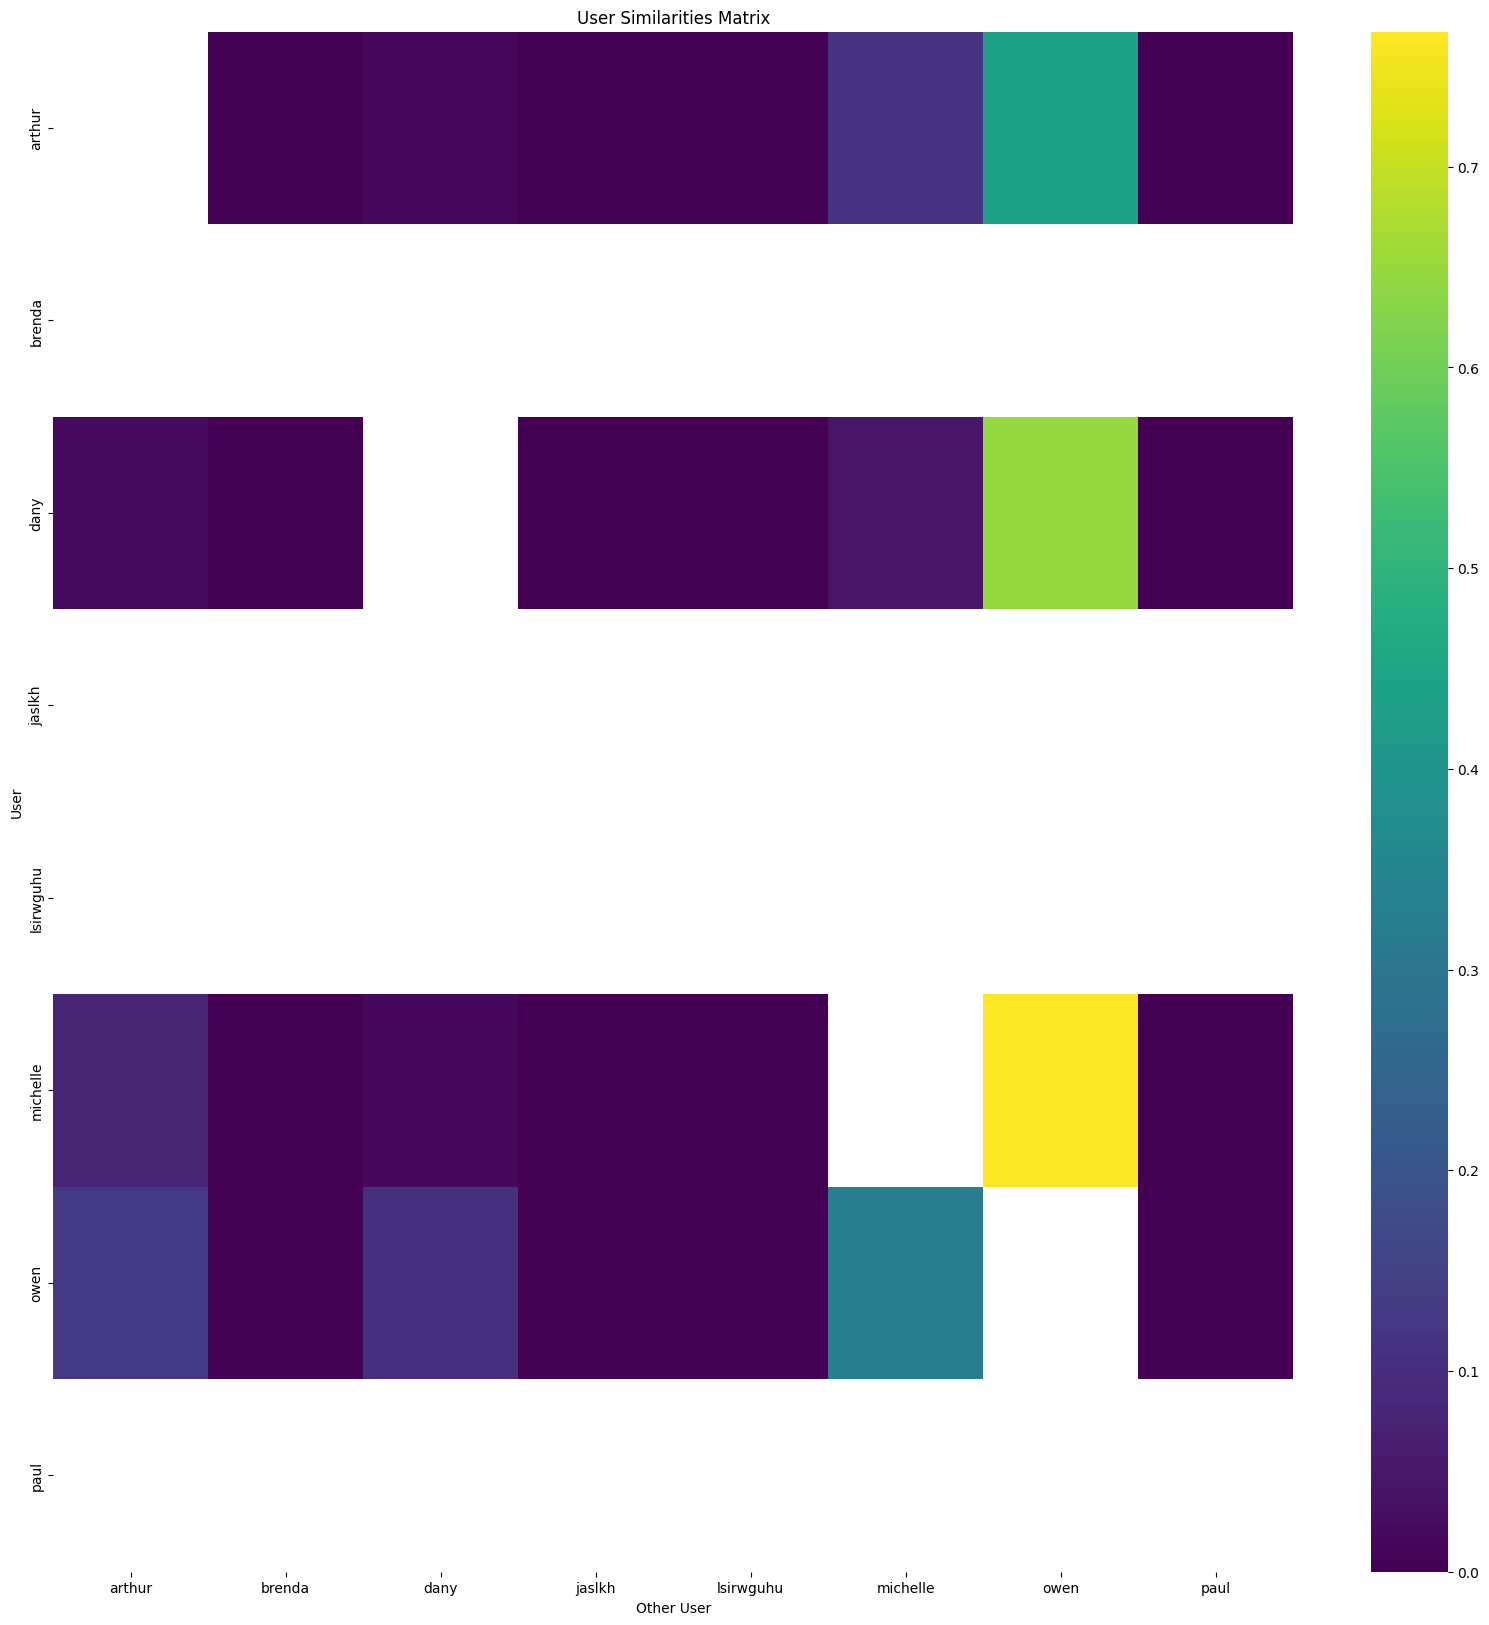

In [15]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False)

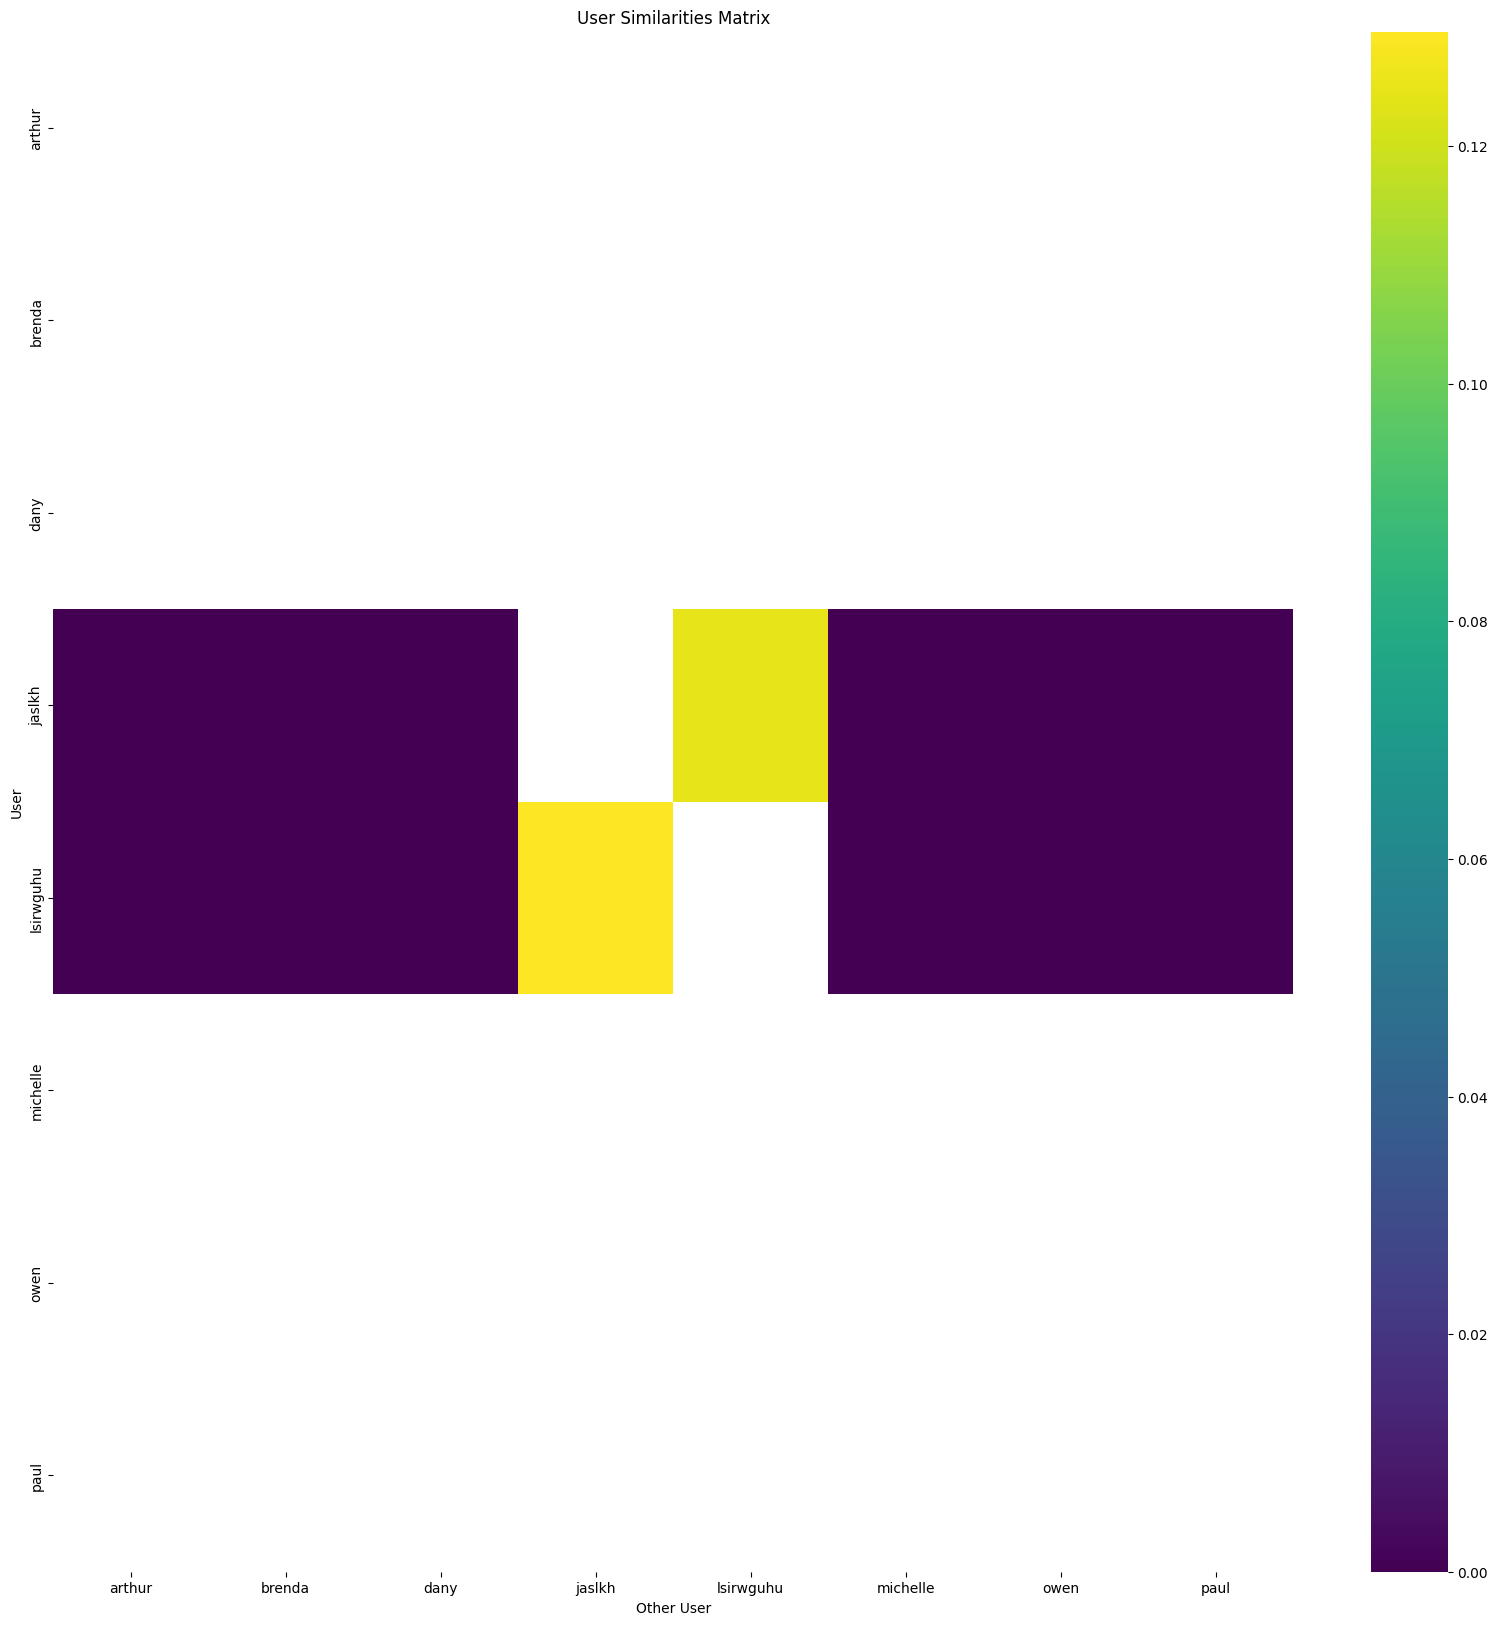

In [16]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False)

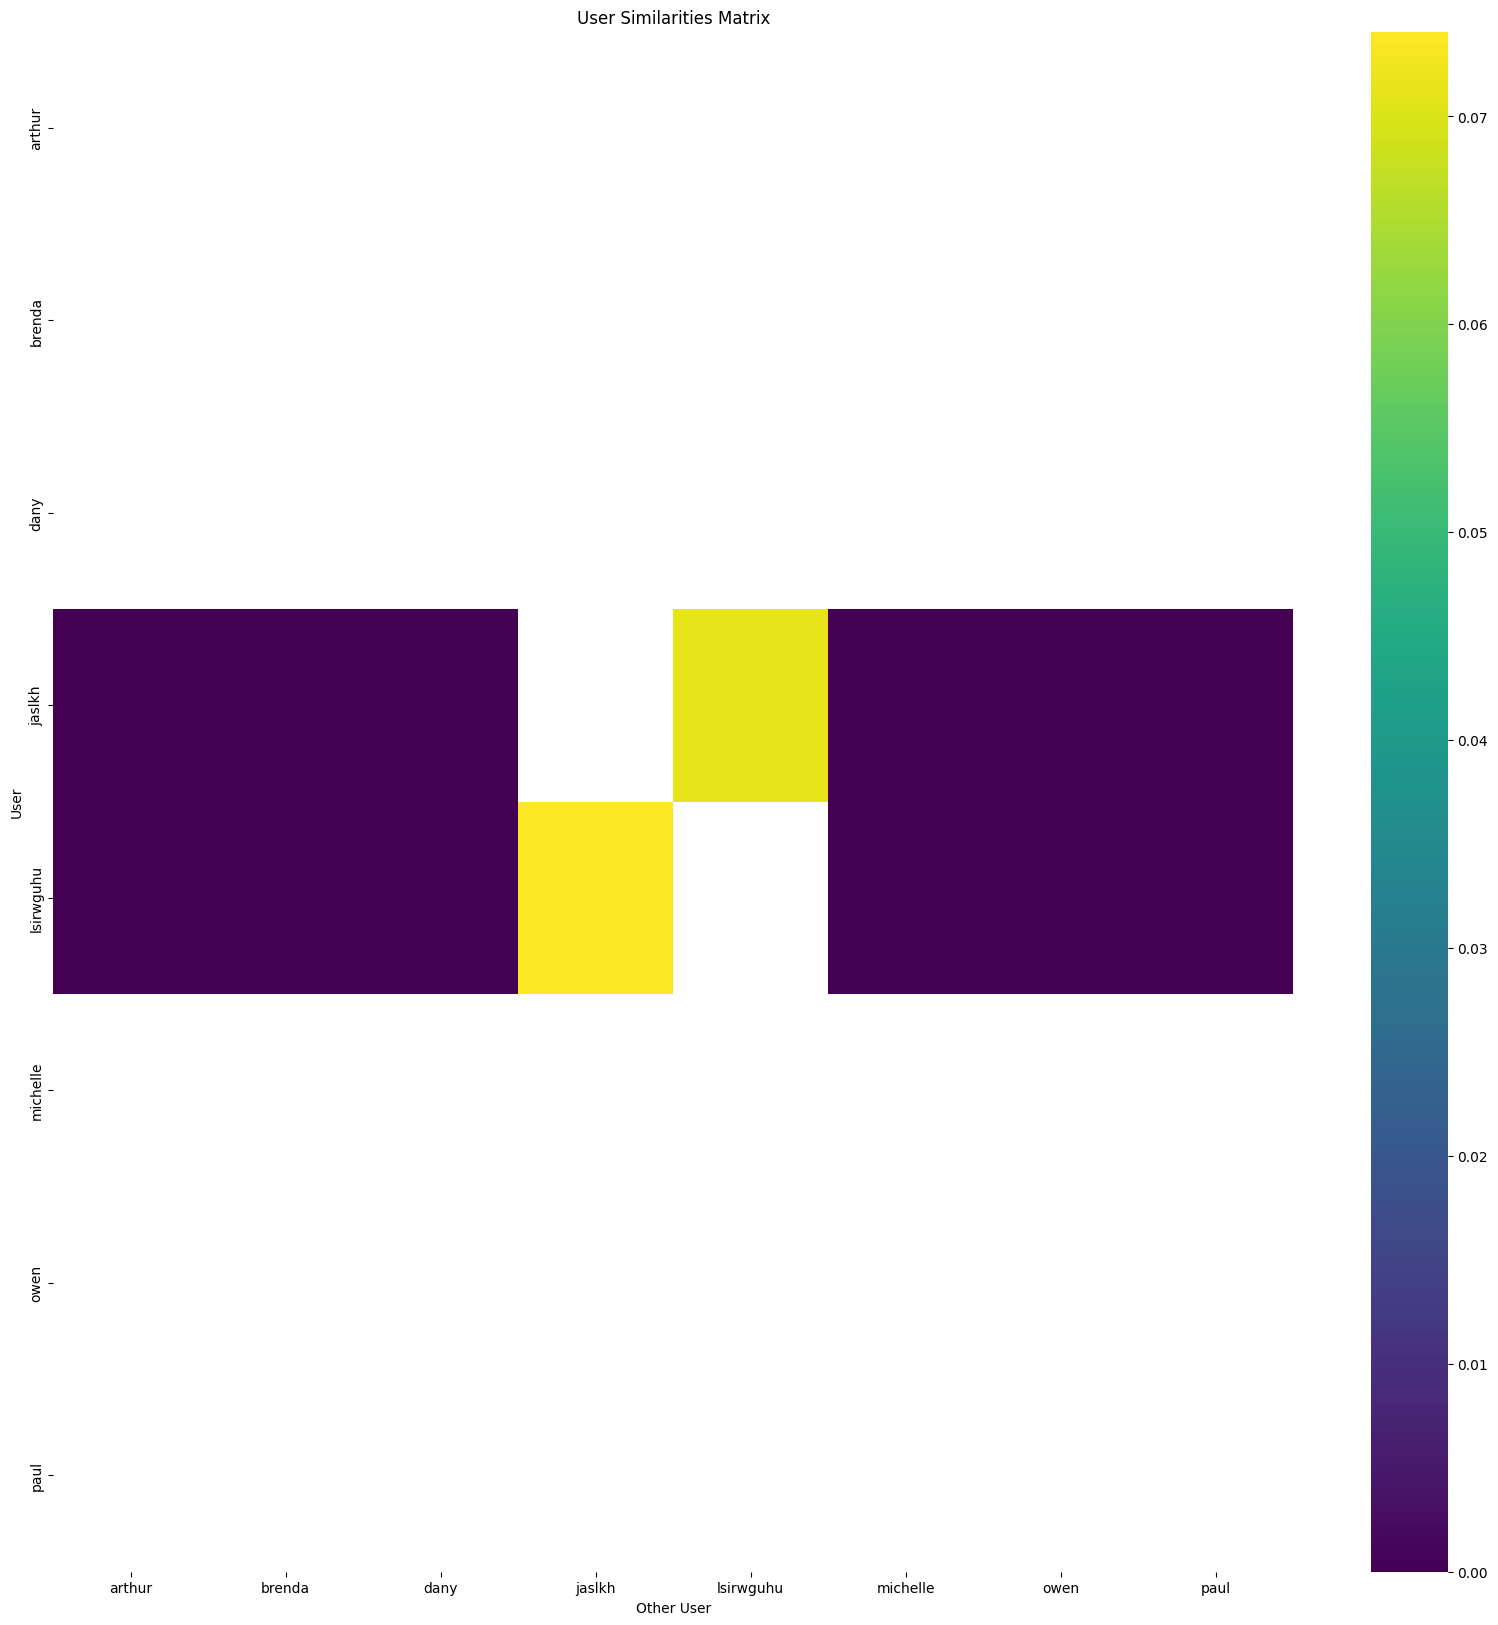

In [17]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False)

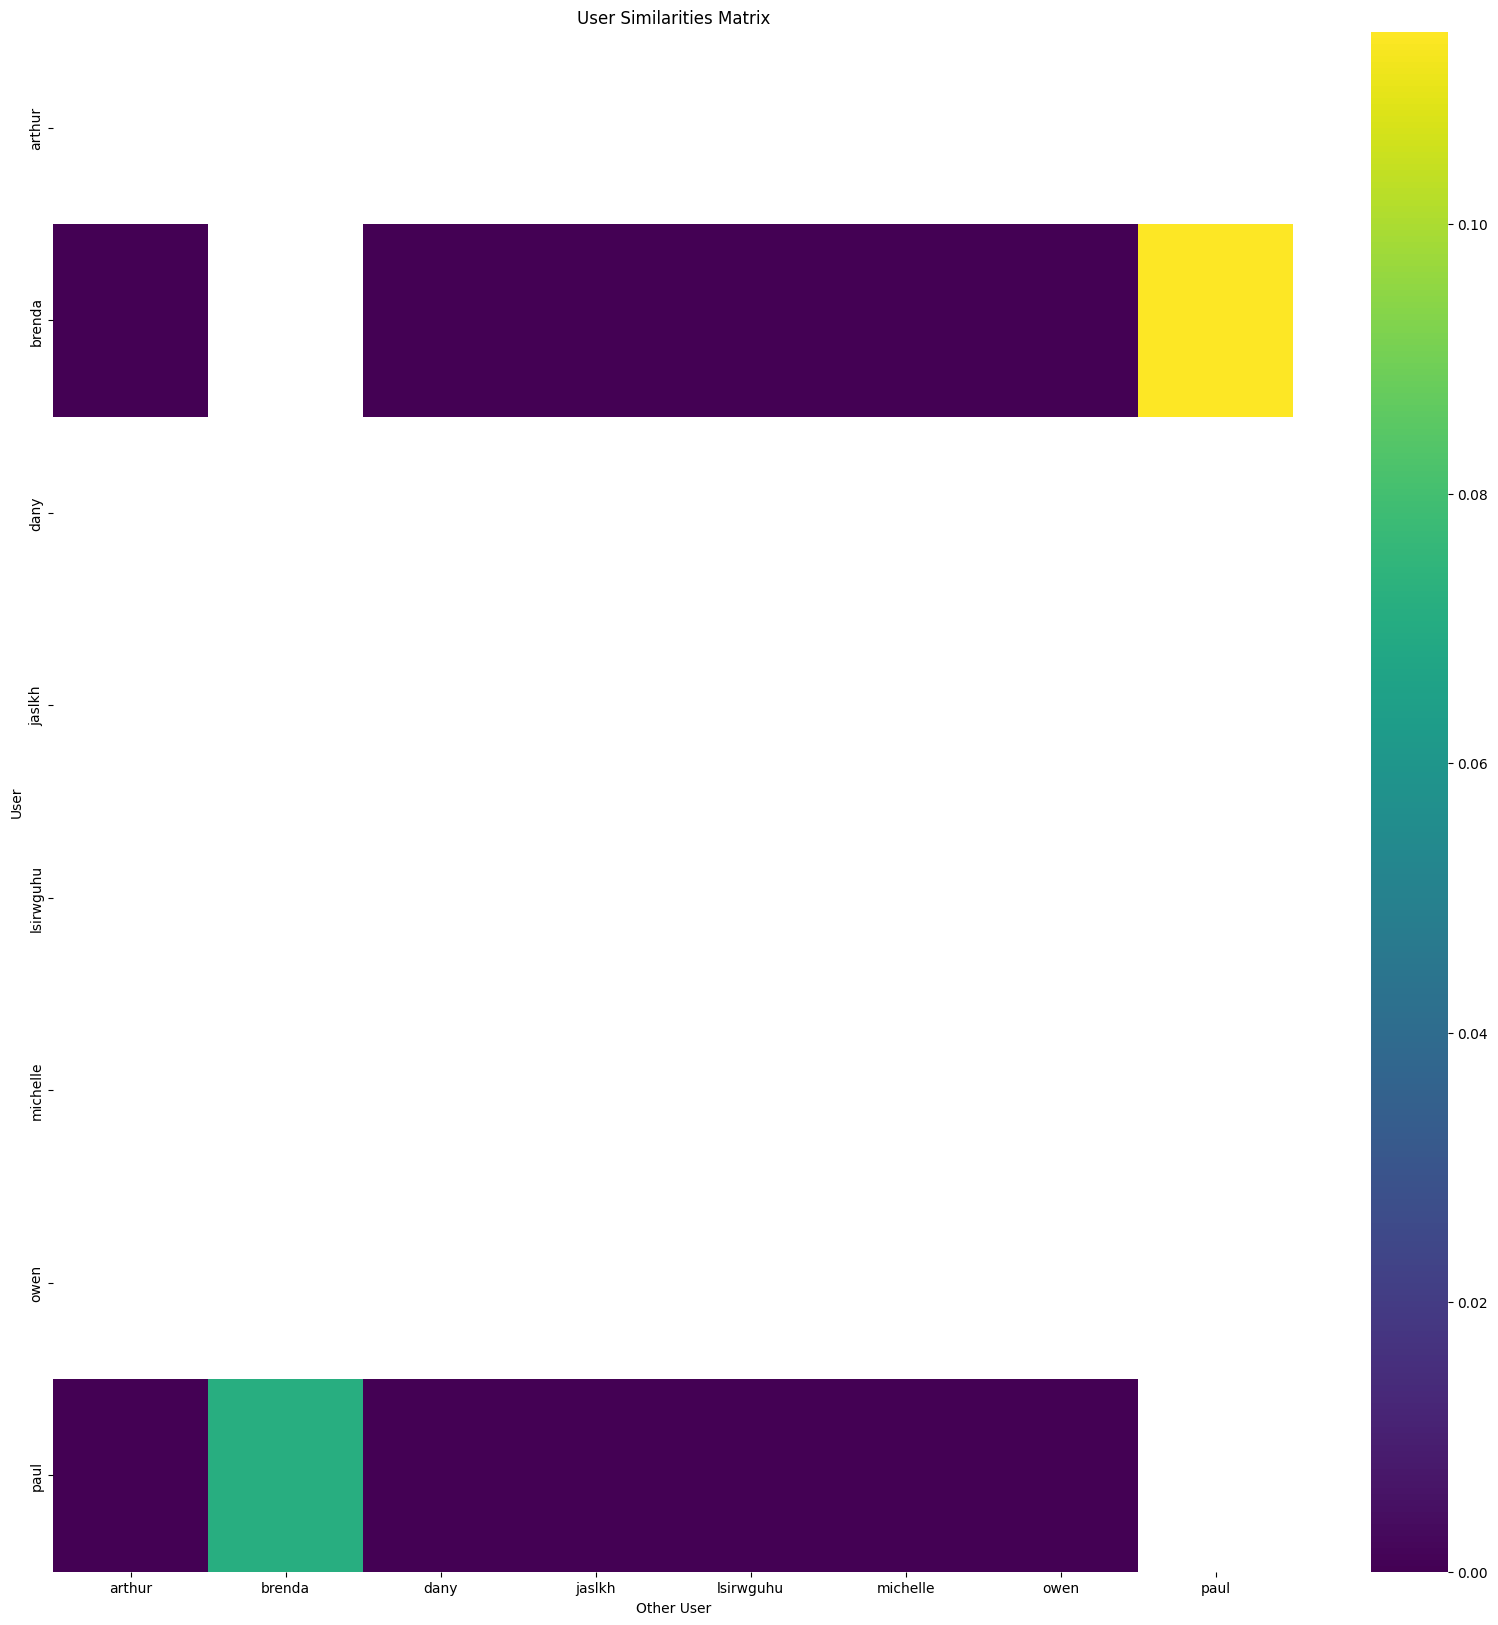

In [18]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False)

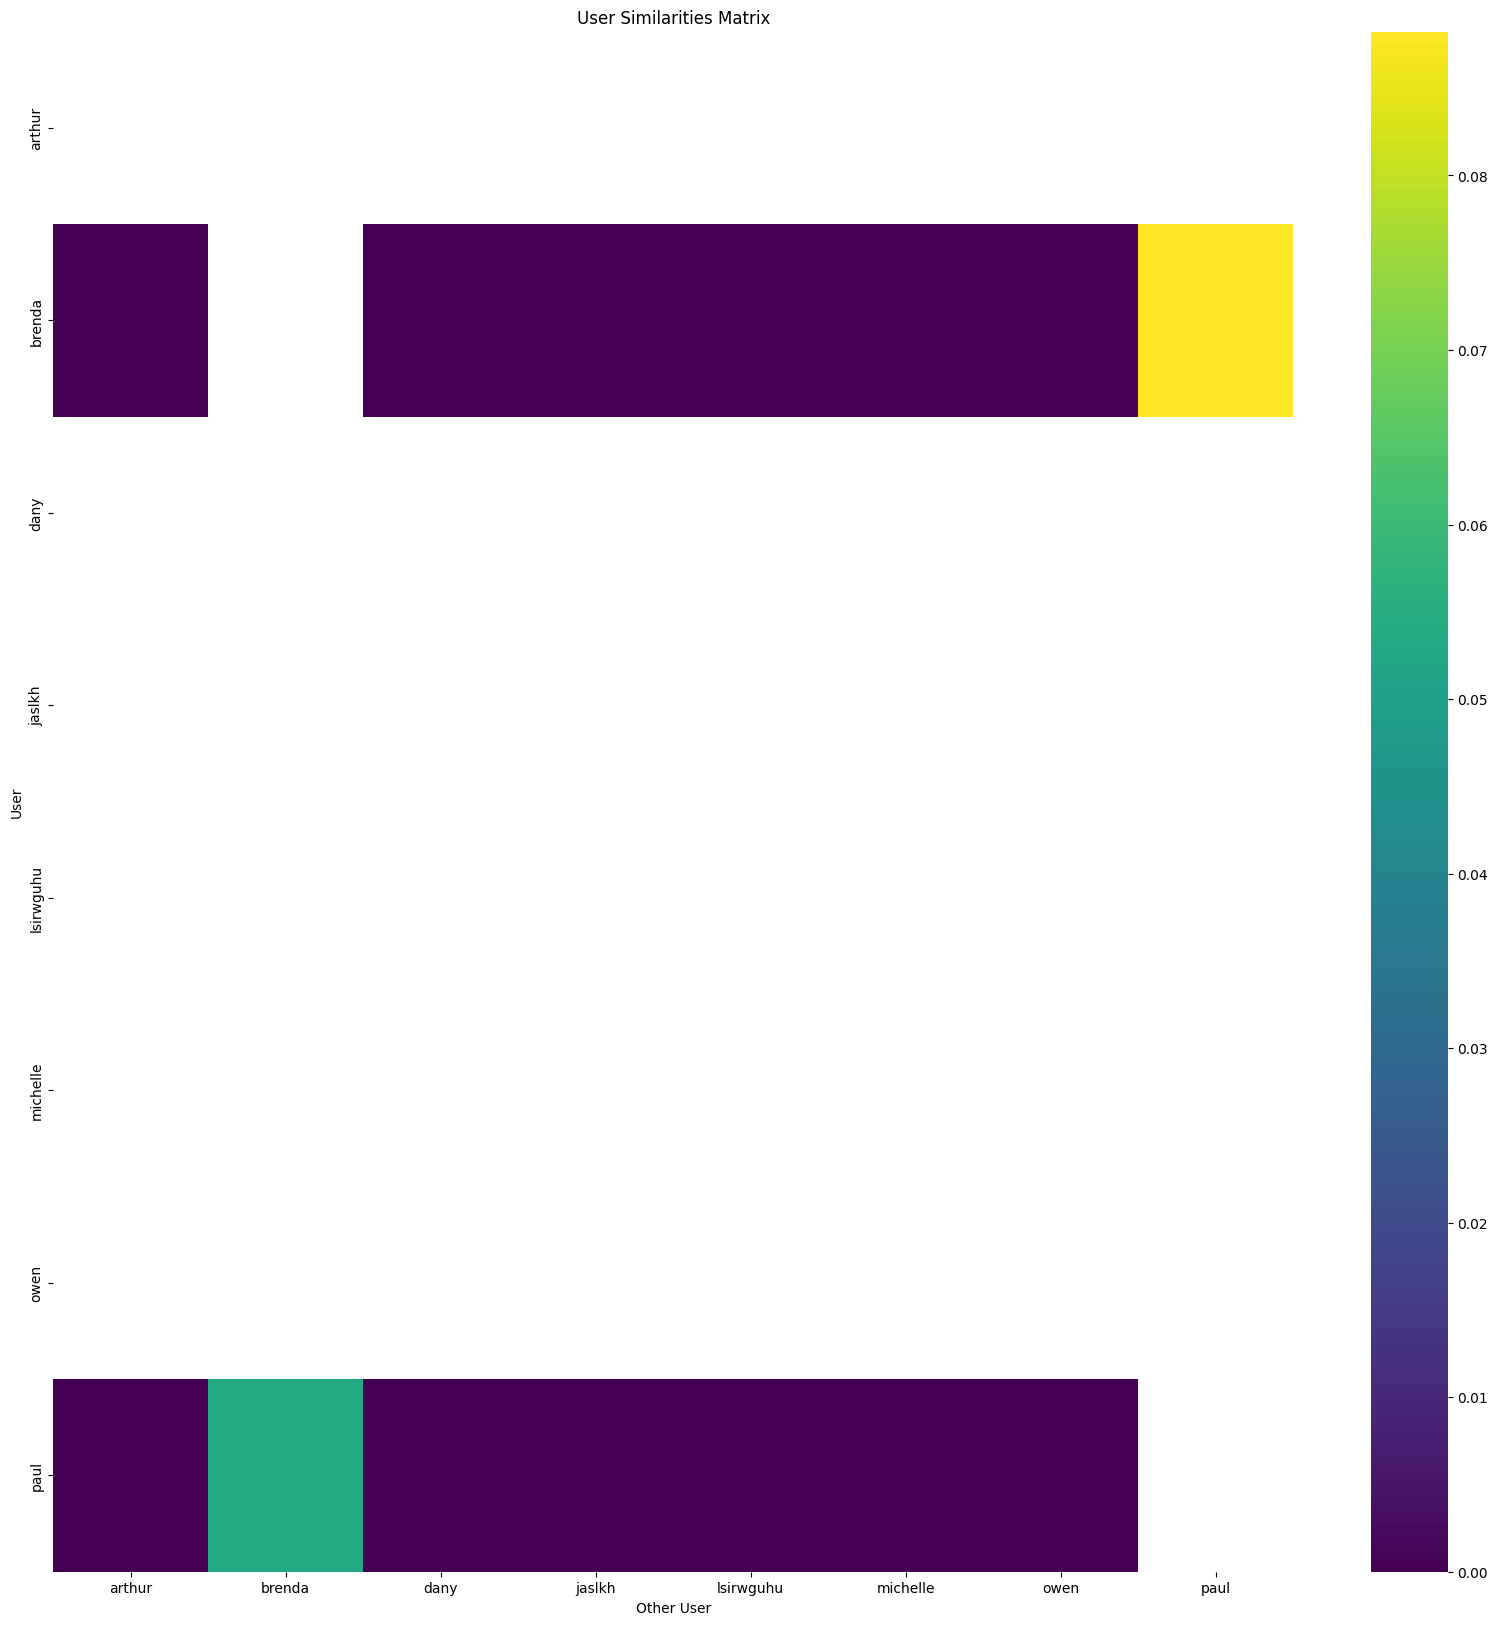

In [19]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False)

In [20]:
(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

In [21]:
a = whole_matrix_dataset.compute_alpha()

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)